# Root Simulate Learning While Walking

This is the main program that simulates learning while walking, converted from the MATLAB version.
Run the cells in order from top to bottom.

## 1. Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Parameters

In [2]:
# Import functions for loading parameters
from parameter_loading.load_biped_model_parameters import load_biped_model_parameters
from parameter_loading.load_sensory_noise_parameters import load_sensory_noise_parameters
from parameter_loading.load_controller_gain_parameters import load_controller_gain_parameters
from parameter_loading.load_learner_parameters import load_learner_parameters
from parameter_loading.load_protocol_parameters import load_protocol_parameters
from parameter_loading.load_stored_memory_parameters_control_vs_speed import load_stored_memory_parameters_control_vs_speed

In [3]:
# Initialize parameters
param_fixed = {}
np.random.seed() 

# Load parameters 
param_fixed = load_biped_model_parameters(param_fixed)
param_fixed = load_sensory_noise_parameters(param_fixed)
param_controller_gains = load_controller_gain_parameters(param_fixed)
param_fixed = load_learner_parameters(param_fixed)
param_fixed = load_protocol_parameters(param_fixed)
param_fixed = load_stored_memory_parameters_control_vs_speed(param_fixed)

print("Parameters loaded successfully!")
print(f"Default number of learning iterations: {param_fixed.get('num_iterations', 'Unknown')}")

Parameters loaded successfully!
Default number of learning iterations: 3200


## 3. Initialize Body Parameters and Context

In [4]:
from initializing.load_learnable_parameters_initial import load_learnable_parameters_initial
from initializing.load_initial_body_state import load_initial_body_state
from initializing.get_treadmill_speed import get_treadmill_speed

In [5]:
# Load initial learnable parameters and body state
p_input_controller_asymmetric_nominal = load_learnable_parameters_initial(param_fixed)
state_var0_model = load_initial_body_state(p_input_controller_asymmetric_nominal)
t_start = 0

# Store initial state for later use in post-processing
state_var0_model_before_learning = state_var0_model.copy()

print("Initial controller parameters:", p_input_controller_asymmetric_nominal)
print("Initial body state:", state_var0_model)

Initial controller parameters: [ 3.28221263e-01  3.10751797e-01  1.53556844e-01  0.00000000e+00
  0.00000000e+00  3.28221491e-01  3.10751695e-01  1.53557221e-01
 -3.89537350e-08 -3.89537350e-08]
Initial body state: [0.        0.3107518 0.        0.        0.35     ]


In [6]:
# Get context for the gait (treadmill speeds)
vA, vB = get_treadmill_speed(0, param_fixed['imposedFootSpeeds'])
context_now = np.array([vA, vB])
context_length = len(context_now)

print("Treadmill speeds (context):", context_now)

Treadmill speeds (context): [-0.3276 -0.3276]


## 4. Learning Simulation

In [7]:
from learning.simulate_learning_step_by_step import simulate_learning_step_by_step

In [8]:
# IMPORTANT: Set number of iterations for simulation
# For testing: use a small number (e.g., 10)
# For full simulation: use the original value (3200)
param_fixed['num_iterations'] = 100  # Change this to 3200 for full simulation

print(f"Running learning simulation with {param_fixed['num_iterations']} iterations...")

# Run the learning simulation
pInputControllerStore_OnesTried = simulate_learning_step_by_step(
    param_fixed,
    p_input_controller_asymmetric_nominal, 
    state_var0_model,
    context_now,
    param_controller_gains
)

print(f"Learning simulation completed! Result shape: {pInputControllerStore_OnesTried.shape}")

Running learning simulation with 10 iterations...
Simulating Learning While Walking ... (10 strides)
Learning simulation completed! Result shape: (8, 10)


## 5. Convert 8D to 10D Format

In [9]:
# Convert the 8D back up to 10D to use the old functions (following MATLAB code)
pInputControllerStore_8D = pInputControllerStore_OnesTried
pInputControllerStore_10D = np.vstack([
    pInputControllerStore_8D[:3, :],   # First 3 rows
    np.zeros((2, pInputControllerStore_8D.shape[1])),  # Add 2 rows of zeros  
    pInputControllerStore_8D[3:8, :]   # Rows 4-8 from original
])

print(f"Converted from 8D shape {pInputControllerStore_8D.shape} to 10D shape {pInputControllerStore_10D.shape}")
print("First few columns of 10D result:")
print(pInputControllerStore_10D[:, :min(3, pInputControllerStore_10D.shape[1])])

Converted from 8D shape (8, 10) to 10D shape (10, 10)
First few columns of 10D result:
[[ 3.27411022e-01  3.23239832e-01  3.23913186e-01]
 [ 3.11347806e-01  3.08917856e-01  3.12234154e-01]
 [ 1.52334860e-01  1.49608112e-01  1.55275644e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 3.28621491e-01  3.29035677e-01  3.27582154e-01]
 [ 3.13341161e-01  3.07194477e-01  3.09798200e-01]
 [ 1.54640475e-01  1.52399847e-01  1.49556623e-01]
 [-3.10140388e-03 -1.55140546e-03 -1.44034775e-04]
 [-1.97326994e-03 -1.51146250e-03 -2.03838373e-03]]


## 6. Post-Processing and Visualization

In [10]:
# Import post-processing functions
from post_processing.post_process_after_learning import post_process_after_learning
from post_processing.post_process_helper_plots import post_process_helper_plots

In [11]:
# Post-process outputs and make plots
do_animate = False  # Set to True if you want animations (not fully implemented yet)

print("Starting post-processing...")

(
    final_state,
    t_store_full,
    state_store_full,
    emet_total_store_full,
    emet_per_time_store_full,
    t_step_store_full,
    ework_pushoff_store_full,
    ework_heelstrike_store_full,
    edot_store_iteration_average,
    t_total_iteration_store,
) = post_process_after_learning(
    pInputControllerStore_10D,
    state_var0_model_before_learning,
    param_controller_gains,
    param_fixed,
    do_animate
)

print("Post-processing completed!")

Starting post-processing...
Post-processing all the walking data ... (10 iterations)
Post-processing complete!
Total steps simulated: 20
Average energy consumption: 0.046939
Final energy consumption: 0.048585
Post-processing completed!


Creating plots...
\n=== Simulation Summary ===
Total steps: 20
Total simulation time: 38.472
Average step duration: 1.9236
Average energy per step: 0.090285
Average energy rate: 0.046945
Initial average energy: 0.047074
Final average energy: 0.048585
Energy improvement: -3.21%


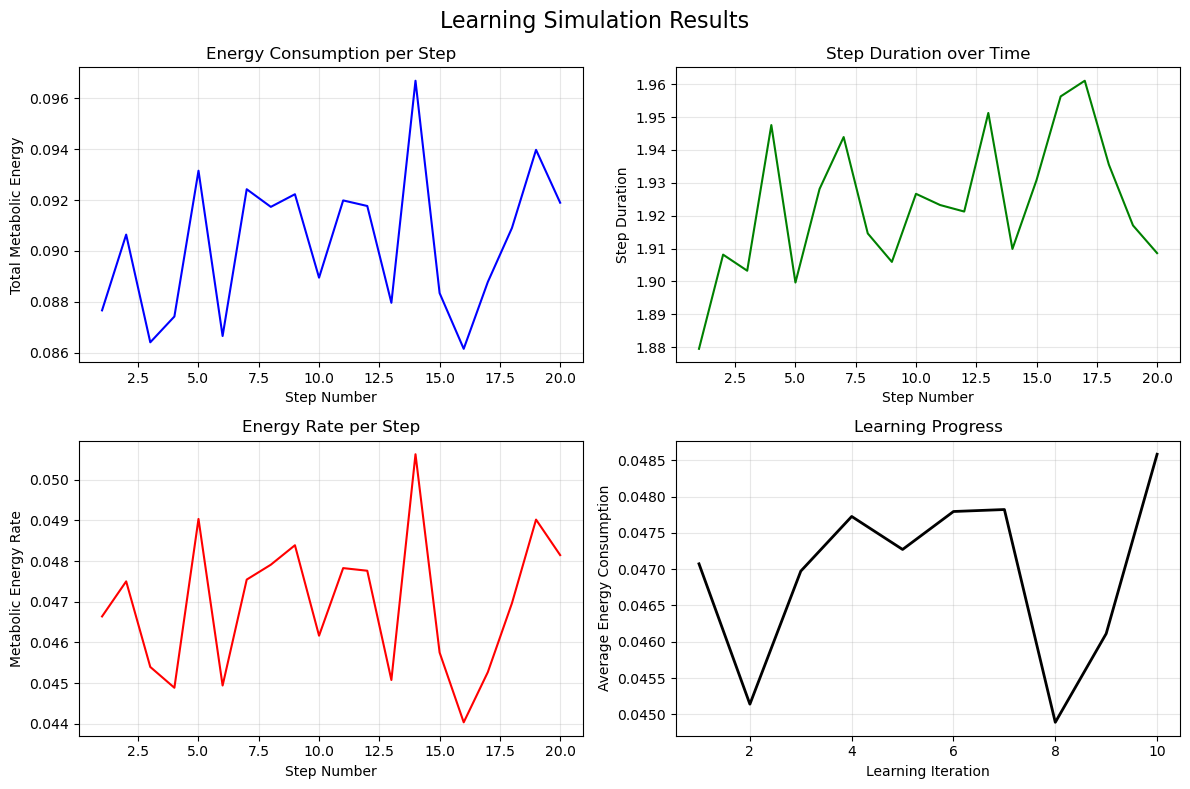

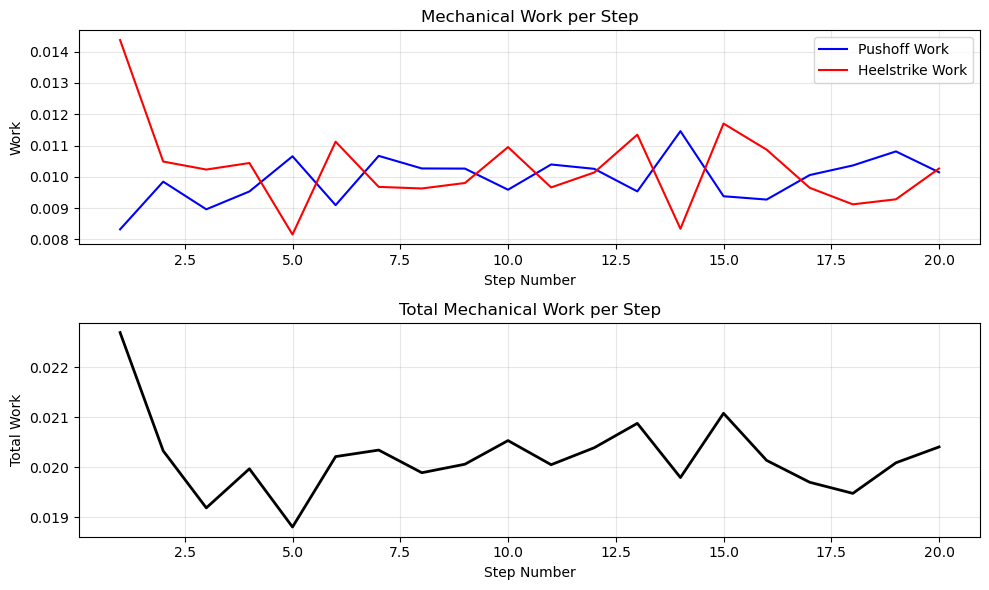


Simulation and analysis complete!


In [12]:
# Create plots and summary statistics
print("Creating plots...")

post_process_helper_plots(
    final_state,
    t_store_full,
    state_store_full,
    emet_total_store_full,
    emet_per_time_store_full,
    t_step_store_full,
    param_controller_gains,
    param_fixed,
    do_animate,
    ework_pushoff_store_full,
    ework_heelstrike_store_full,
    edot_store_iteration_average,
    t_total_iteration_store,
)

print("\nSimulation and analysis complete!")

## Summary

This notebook has successfully converted and run the MATLAB learning simulation in Python. The simulation includes:

1. **Parameter Loading**: All model, controller, learner, and protocol parameters
2. **Initialization**: Initial body state and controller parameters
3. **Learning Simulation**: Step-by-step reinforcement learning
4. **Post-Processing**: Detailed trajectory analysis and energy consumption
5. **Visualization**: Plots showing learning progress and simulation results

To run the full-scale simulation (3200 iterations), change `param_fixed['num_iterations'] = 10` to `param_fixed['num_iterations'] = 3200` in the learning simulation section.